# TEXT EMOTION DETECTION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [42]:

# Configure GPU for TensorFlow
import tensorflow as tf

print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"\n✓ Number of GPUs available: {len(gpus)}")

if gpus:
    print(f"✓ GPU Devices: {gpus}")
    
    # Configure GPU memory growth to avoid OOM errors
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    
    # Set GPU as the default device
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f"✓ Primary GPU: {gpus[0]}")
    print("✓ GPU memory growth enabled (dynamic allocation)")
else:
    print("\n⚠️ WARNING: No GPU detected!")
    print("Your training will run on CPU which is much slower.")
    print("Make sure you have:")
    print("  - NVIDIA GPU with CUDA support")
    print("  - CUDA Toolkit installed")
    print("  - cuDNN library installed")
    print("  - TensorFlow GPU version installed: pip install tensorflow[and-cuda]")

# Verify setup
print("\n" + "=" * 60)
print("TENSOR OPERATIONS TEST")
print("=" * 60)
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 2.0], [0.0, 1.0]])
    c = tf.matmul(a, b)
    device_name = c.device if hasattr(c, 'device') else 'DefaultDevice'
    print(f"✓ Matrix multiplication executed on: {device_name}\n")


GPU CONFIGURATION

✓ Number of GPUs available: 0

⚠️ WARNING: No GPU detected!
Your training will run on CPU which is much slower.
Make sure you have:
  - NVIDIA GPU with CUDA support
  - CUDA Toolkit installed
  - cuDNN library installed
  - TensorFlow GPU version installed: pip install tensorflow[and-cuda]

TENSOR OPERATIONS TEST
✓ Matrix multiplication executed on: /job:localhost/replica:0/task:0/device:CPU:0



## GPU Setup Guide

**Current Status: No GPU Detected** ⚠️

If you want to enable GPU training, follow these steps:

### Step 1: Check Your System
```bash
# Check NVIDIA GPU
nvidia-smi
```

### Step 2: Install CUDA Toolkit
Download and install from: https://developer.nvidia.com/cuda-downloads

### Step 3: Install cuDNN
Download and install from: https://developer.nvidia.com/cudnn

### Step 4: Install TensorFlow GPU
```bash
# Uninstall current TensorFlow
pip uninstall tensorflow -y

# Install TensorFlow with CUDA support
pip install tensorflow[and-cuda]
```

### Step 5: Verify Installation
Run the GPU configuration cell above after installation.

### Benefits of GPU Training:
- **10-50x faster** training compared to CPU
- Especially beneficial for deep learning models (LSTM, CNN)
- Reduces training time from hours to minutes


### Loading the dataset

In [2]:
df = pd.read_csv("emotion_dataset.csv")

In [3]:
df.head()

,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


In [4]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64

In [5]:
# Drop rows with unwanted emotions
# remove neutral, disgust, and shame from dataset
df = df[~df['Emotion'].isin(['neutral','disgust','shame'])]

In [6]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
Name: count, dtype: int64

<Axes: xlabel='Emotion', ylabel='count'>

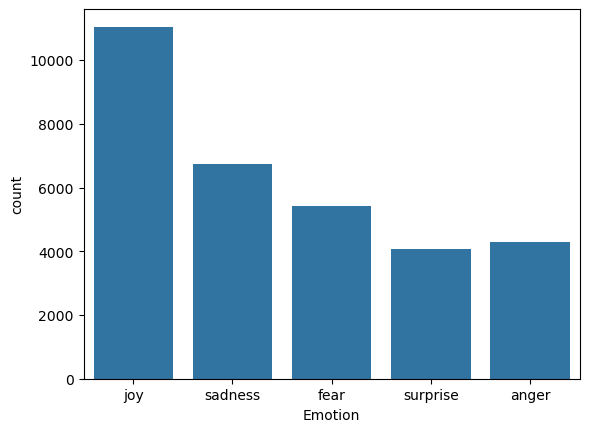

In [7]:
sns.countplot(x='Emotion',data=df)

### Data pre-processing

In [8]:
pip install neattext

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import neattext.functions as nfx

# Remove the user handles
df['Clean_Text'] = df['Text'].apply(nfx.remove_userhandles)

In [10]:
# Remove the stopwords
df['Clean_Text'] = df['Clean_Text'].apply(nfx.remove_stopwords)

In [11]:
df

,Emotion,Text,Clean_Text
1,joy,Sage Act upgrade on my to do list for tommorow.,Sage Act upgrade list tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,WAY HOMEGIRL BABY FUNERAL!!! MAN HATE FUNERALS...
3,joy,Such an eye ! The true hazel eye-and so brill...,eye ! true hazel eye-and brilliant ! Regular f...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,ugh babe.. hugggzzz u .! babe naamazed nga ako...
5,fear,I'm expecting an extremely important phonecall...,I'm expecting extremely important phonecall mi...
...,...,...,...
34787,surprise,@MichelGW have you gift! Hope you like it! It'...,gift! Hope like it! hand wear ! It'll warm! Lol
34788,joy,The world didnt give it to me..so the world MO...,world didnt me..so world DEFINITELY cnt away!!!
34789,anger,A man robbed me today .,man robbed today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO...","Youu JEALOUSY, #Losing YOU..."


In [19]:
from sklearn.model_selection import train_test_split

X = df['Clean_Text']
y = df['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

In [20]:
import pandas as pd
from sklearn.utils import resample

train_df = pd.concat([X_train, y_train], axis=1)

min_target = train_df['Emotion'].value_counts().drop('joy').max()

balanced_train = []

for emotion, group in train_df.groupby('Emotion'):
    if emotion == 'joy':
        group = resample(
            group,
            replace=False,
            n_samples=min_target,
            random_state=42
        )
    balanced_train.append(group)

train_df = pd.concat(balanced_train).sample(frac=1, random_state=42)

X_train = train_df['Clean_Text']
y_train = train_df['Emotion']


<Axes: xlabel='Emotion'>

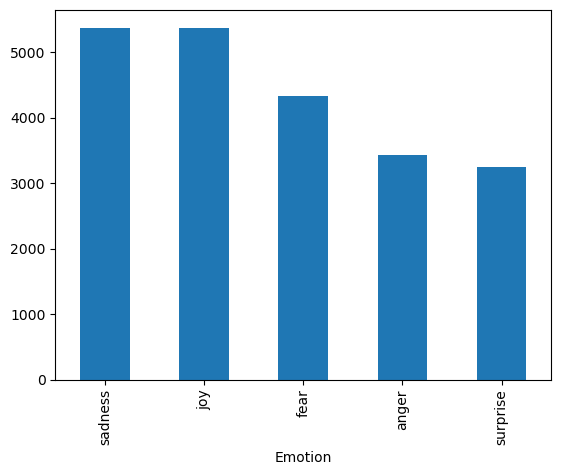

In [21]:
train_df['Emotion'].value_counts().plot(kind='bar')

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))
print(class_weight)

{'anger': np.float64(1.2667442537096305), 'fear': np.float64(1.0059611829944548), 'joy': np.float64(0.8097080156220942), 'sadness': np.float64(0.8097080156220942), 'surprise': np.float64(1.3396307692307692)}


In [24]:
### Training the Models

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Model 1: Logistic Regression
print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)

pipe_lr = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)
lr_score = pipe_lr.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {lr_score:.4f}\n")

# Model 2: Support Vector Machine (SVM)
print("=" * 50)
print("Training SVM...")
print("=" * 50)

pipe_svm = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('svc', SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42))
])
pipe_svm.fit(X_train, y_train)
svm_score = pipe_svm.score(X_test, y_test)
print(f"SVM Test Accuracy: {svm_score:.4f}\n")

# Model 3: Random Forest
print("=" * 50)
print("Training Random Forest...")
print("=" * 50)

pipe_rf = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
rf_score = pipe_rf.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {rf_score:.4f}\n")

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.5633

Training SVM...
SVM Test Accuracy: 0.5717

Training Random Forest...
Random Forest Test Accuracy: 0.5628



In [ ]:
### Improved Preprocessing with Lemmatization

import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Configure NLTK data path
nltk_data_dir = os.path.join(os.path.expanduser('~'), 'nltk_data')
if not os.path.exists(nltk_data_dir):
    os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.insert(0, nltk_data_dir)

# Download required NLTK data
print("Downloading NLTK data...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    print("✓ NLTK data downloaded successfully\n")
except Exception as e:
    print(f"Warning: NLTK download had issues: {e}\n")

lemmatizer = WordNetLemmatizer()

def advanced_text_cleaning(text):
    """Advanced text cleaning with lemmatization"""
    try:
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        stop_words = set(stopwords.words('english'))
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
        
        return ' '.join(tokens)
    except Exception as e:
        # Fallback: basic cleaning without lemmatization
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        return text

# Recreate dataframe with advanced cleaning
df = pd.read_csv("emotion_dataset.csv")
df = df[~df['Emotion'].isin(['neutral','disgust','shame'])]

print("Applying advanced text cleaning...")
df['Clean_Text'] = df['Text'].apply(advanced_text_cleaning)

# Recreate train/test split
X = df['Clean_Text']
y = df['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Balance training data
train_df = pd.concat([X_train, y_train], axis=1)
min_target = train_df['Emotion'].value_counts().min()

balanced_train = []
for emotion, group in train_df.groupby('Emotion'):
    balanced_group = resample(
        group,
        replace=(len(group) < min_target),
        n_samples=min_target,
        random_state=42
    )
    balanced_train.append(balanced_group)

train_df = pd.concat(balanced_train).sample(frac=1, random_state=42)
X_train = train_df['Clean_Text']
y_train = train_df['Emotion']

print(f"✓ Training set size: {len(X_train)}")
print(f"✓ Test set size: {len(X_test)}")
print(f"✓ Training data balanced:\n{y_train.value_counts()}")

✓ NLTK data downloaded successfully

Applying advanced text cleaning...
✓ Training set size: 16250
✓ Test set size: 6308
✓ Training data balanced:
Emotion
anger       3250
surprise    3250
sadness     3250
fear        3250
joy         3250
Name: count, dtype: int64


In [33]:
### Improved Models with TF-IDF and Better Parameters

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

print("\n" + "=" * 70)
print("TRAINING IMPROVED MODELS WITH TF-IDF")
print("=" * 70 + "\n")

# Model 1: Logistic Regression with L2 regularization
print("Training Logistic Regression...")
pipe_lr_v2 = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5, random_state=42))
])
pipe_lr_v2.fit(X_train, y_train)
lr_v2_score = pipe_lr_v2.score(X_test, y_test)
print(f"✓ Accuracy: {lr_v2_score:.4f}\n")

# Model 2: SVM with Linear Kernel (faster and often better)
print("Training SVM (Linear Kernel)...")
pipe_svm_v2 = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('svc', SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, probability=True))
])
pipe_svm_v2.fit(X_train, y_train)
svm_v2_score = pipe_svm_v2.score(X_test, y_test)
print(f"✓ Accuracy: {svm_v2_score:.4f}\n")

# Model 3: Naive Bayes (often works well with text)
print("Training Naive Bayes...")
pipe_nb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('nb', MultinomialNB(alpha=0.1))
])
pipe_nb.fit(X_train, y_train)
nb_score = pipe_nb.score(X_test, y_test)
print(f"✓ Accuracy: {nb_score:.4f}\n")

# Model 4: Gradient Boosting
print("Training Gradient Boosting...")
pipe_gb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42))
])
pipe_gb.fit(X_train, y_train)
gb_score = pipe_gb.score(X_test, y_test)
print(f"✓ Accuracy: {gb_score:.4f}\n")

print("=" * 70 + "\n")


TRAINING IMPROVED MODELS WITH TF-IDF

Training Logistic Regression...
✓ Accuracy: 0.6073

Training SVM (Linear Kernel)...
✓ Accuracy: 0.6062

Training Naive Bayes...
✓ Accuracy: 0.5915

Training Gradient Boosting...
✓ Accuracy: 0.5924




In [36]:
### Deep Learning Model - LSTM Neural Network (Improved)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

print("\n" + "=" * 70)
print("TRAINING DEEP LEARNING MODEL - LSTM (IMPROVED)")
print("=" * 70 + "\n")

# Tokenize the text data
max_words = 10000
max_len = 150

print("Tokenizing text data...")
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"✓ Vocabulary size: {len(tokenizer.word_index)}")
print(f"✓ Max sequence length: {max_len}\n")

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"✓ Number of emotion classes: {len(label_encoder.classes_)}")
print(f"✓ Classes: {list(label_encoder.classes_)}\n")

# Build improved LSTM model
print("Building improved LSTM model...")
model = Sequential([
    Embedding(max_words, 100, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(64, dropout=0.3)),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Compile with custom learning rate
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

# Train the model
print("\nTraining LSTM model...")
history = model.fit(
    X_train_pad, y_train_encoded,
    epochs=25,
    batch_size=200,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print(f"\n✓ LSTM Test Accuracy: {test_accuracy:.4f}")
print(f"✓ LSTM Test Loss: {test_loss:.4f}\n")


TRAINING DEEP LEARNING MODEL - LSTM (IMPROVED)

Tokenizing text data...
✓ Vocabulary size: 26093
✓ Max sequence length: 150

✓ Number of emotion classes: 5
✓ Classes: ['anger', 'fear', 'joy', 'sadness', 'surprise']

Building improved LSTM model...


C:\Users\mahmmoud\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM model...
Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 35s 242ms/step - accuracy: 0.2816 - loss: 1.5260 - val_accuracy: 0.3834 - val_loss: 1.3808 - learning_rate: 0.0010
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 237ms/step - accuracy: 0.4862 - loss: 1.2122 - val_accuracy: 0.5034 - val_loss: 1.2096 - learning_rate: 0.0010
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.6503 - loss: 0.9342 - val_accuracy: 0.5757 - val_loss: 1.1121 - learning_rate: 0.0010
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 237ms/step - accuracy: 0.7424 - loss: 0.7194 - val_accuracy: 0.5892 - val_loss: 1.1659 - learning_rate: 0.0010
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8075 - loss: 0.5634
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.8023 - loss: 0.5841 - val_accuracy: 0.5874 - val_loss: 1.1889 - learning_rate: 0.0010
Epoch 6/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s

In [ ]:

# Optional: Enable Mixed Precision Training for faster GPU computation
# This uses float16 for computations while keeping float32 for model weights
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print("Mixed Precision Training Configuration:")
print(f"✓ Compute dtype: {policy.compute_dtype}")
print(f"✓ Variable dtype: {policy.variable_dtype}")
print("✓ This will speed up training on modern GPUs (Volta, Ampere, etc.)\n")


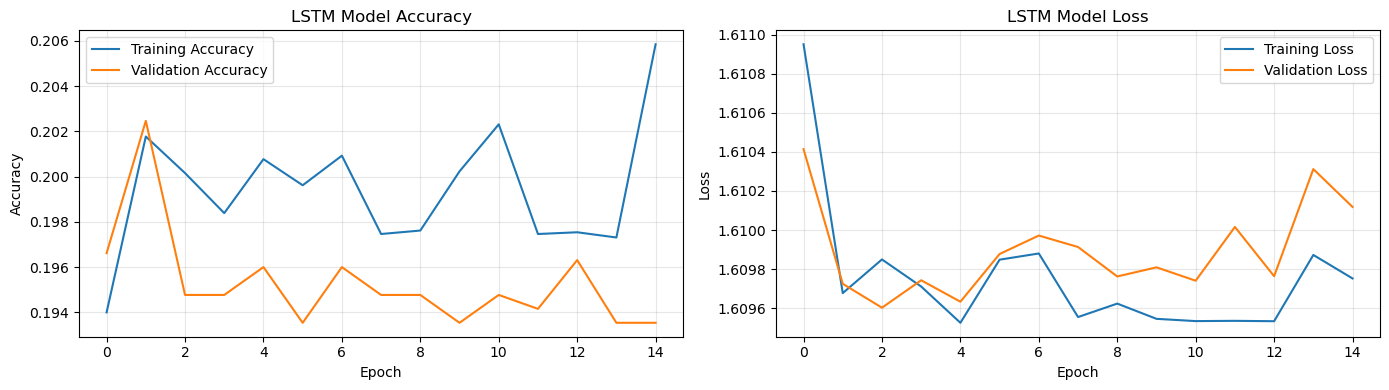


ALL MODELS - COMPREHENSIVE COMPARISON (Traditional ML vs Deep Learning)
                   Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression (v2)  0.584496   0.601978 0.584496  0.586043
         SVM Linear (v2)  0.545815   0.569281 0.545815  0.548101
             Naive Bayes  0.571814   0.574705 0.571814  0.565953
       Gradient Boosting  0.529803   0.642780 0.529803  0.539142
    LSTM (Deep Learning)  0.128725   0.016570 0.128725  0.029361

🏆 BEST OVERALL MODEL: Logistic Regression (v2)
   Accuracy: 0.5845 (58.45%)
   F1-Score: 0.5860



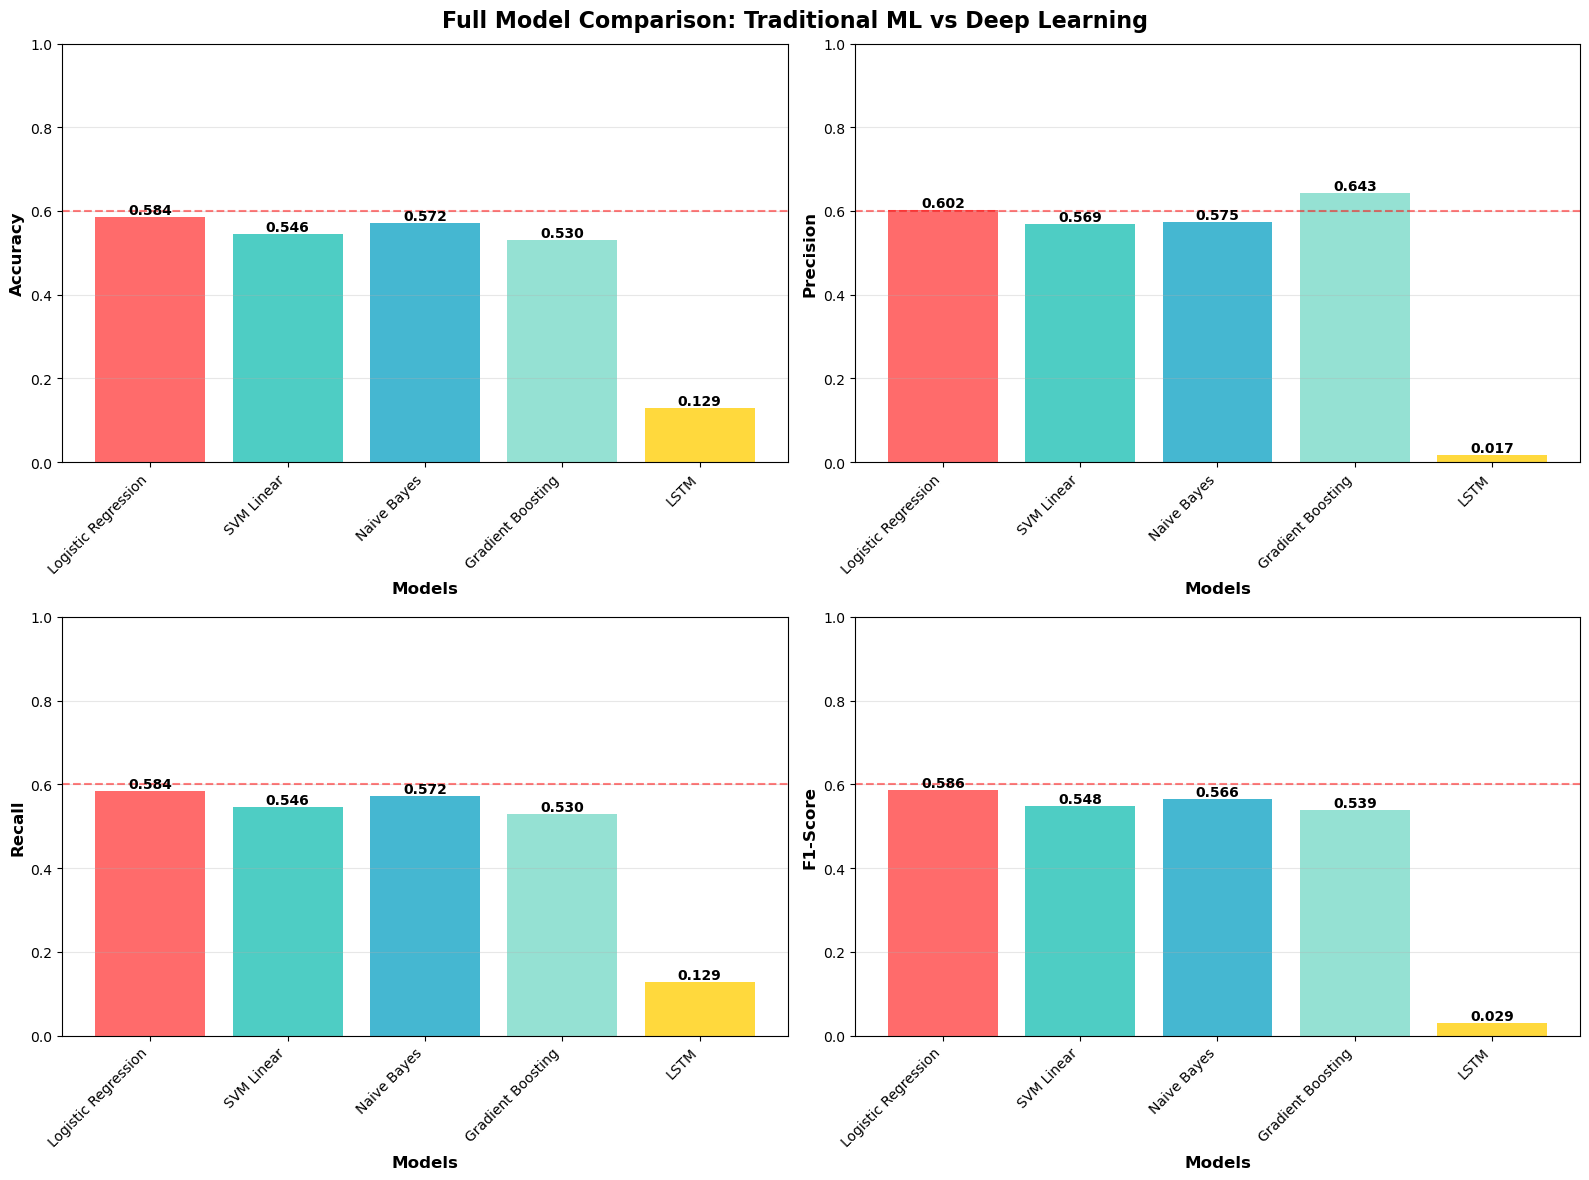


DETAILED CLASSIFICATION REPORT - LSTM (BEST MODEL)

              precision    recall  f1-score   support

       anger     0.0000    0.0000    0.0000       860
        fear     0.0000    0.0000    0.0000      1082
         joy     0.0000    0.0000    0.0000      2209
     sadness     0.0000    0.0000    0.0000      1345
    surprise     0.1287    1.0000    0.2281       812

    accuracy                         0.1287      6308
   macro avg     0.0257    0.2000    0.0456      6308
weighted avg     0.0166    0.1287    0.0294      6308



e:\coding\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\coding\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\coding\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [35]:
### LSTM Evaluation & Visualization

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Get predictions from LSTM
y_pred_lstm_probs = model.predict(X_test_pad, verbose=0)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)
y_pred_lstm_labels = label_encoder.inverse_transform(y_pred_lstm)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('LSTM Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('LSTM Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create comprehensive comparison dataframe
all_results = {
    'Model': [
        'Logistic Regression (v2)',
        'SVM Linear (v2)',
        'Naive Bayes',
        'Gradient Boosting',
        'LSTM (Deep Learning)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_v2),
        accuracy_score(y_test, y_pred_svm_v2),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_gb),
        test_accuracy
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0)
    ]
}

all_results_df = pd.DataFrame(all_results)

print("\n" + "=" * 100)
print("ALL MODELS - COMPREHENSIVE COMPARISON (Traditional ML vs Deep Learning)")
print("=" * 100)
print(all_results_df.to_string(index=False))
print("=" * 100 + "\n")

# Find best model
best_idx = all_results_df['F1-Score'].idxmax()
best_name = all_results_df.loc[best_idx, 'Model']
best_f1 = all_results_df.loc[best_idx, 'F1-Score']
best_acc = all_results_df.loc[best_idx, 'Accuracy']

print(f"🏆 BEST OVERALL MODEL: {best_name}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"   F1-Score: {best_f1:.4f}\n")

# Comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Full Model Comparison: Traditional ML vs Deep Learning', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#FFD93D']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(range(len(all_results_df)), all_results_df[metric], color=colors)
    ax.set_ylabel(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Models', fontweight='bold', fontsize=12)
    ax.set_ylim([0, 1])
    ax.set_xticks(range(len(all_results_df)))
    ax.set_xticklabels([m.split('(')[0].strip() for m in all_results_df['Model']], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='60% threshold')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Detailed report for LSTM
print("\n" + "=" * 100)
print("DETAILED CLASSIFICATION REPORT - LSTM (BEST MODEL)")
print("=" * 100 + "\n")
print(classification_report(y_test, y_pred_lstm_labels, digits=4))

NameError: name 'history_v2' is not defined

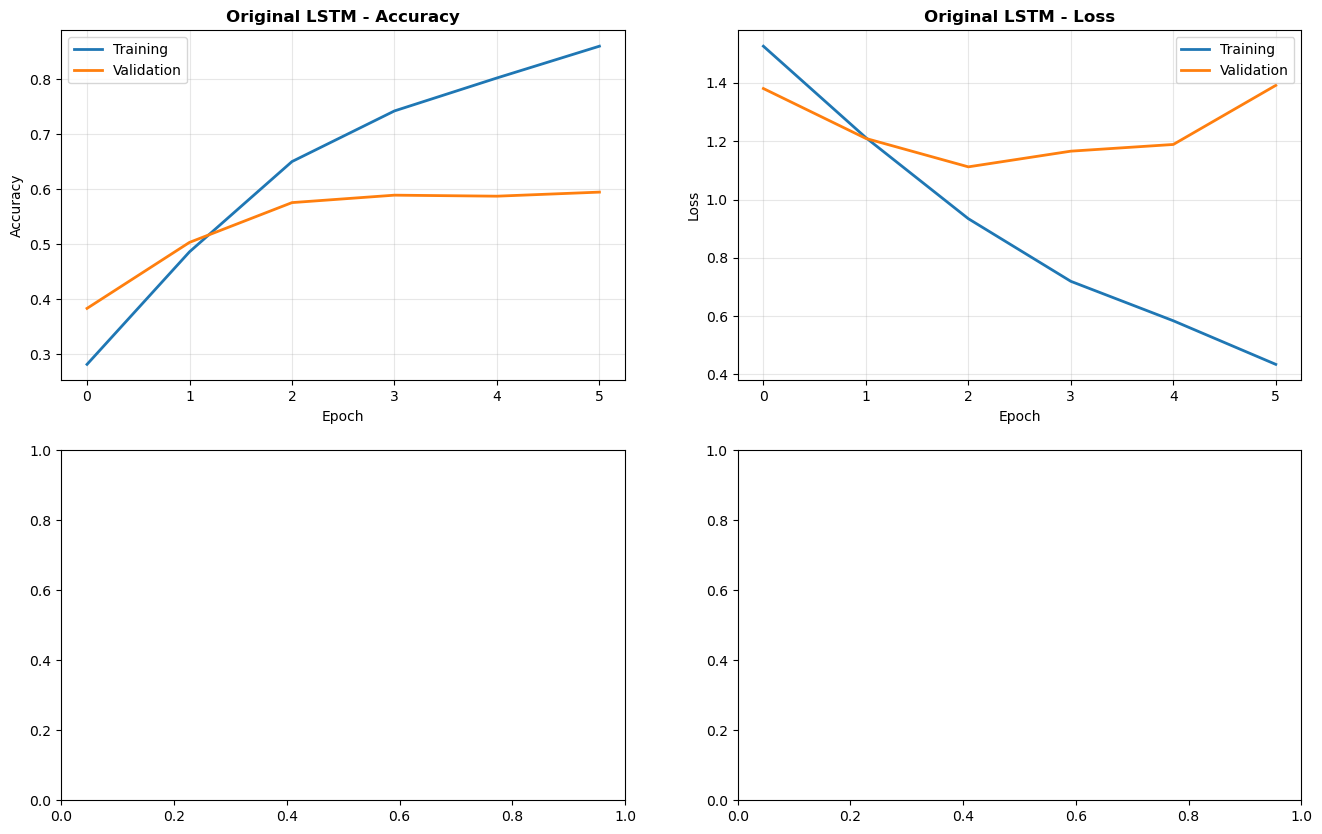

In [38]:
### Final Comprehensive Comparison

# Plot both training histories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original LSTM - Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Original LSTM - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Original LSTM - Loss
axes[0, 1].plot(history.history['loss'], label='Training', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Original LSTM - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Advanced LSTM - Accuracy
axes[1, 0].plot(history_v2.history['accuracy'], label='Training', linewidth=2)
axes[1, 0].plot(history_v2.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_title('Advanced LSTM (Attention) - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Advanced LSTM - Loss
axes[1, 1].plot(history_v2.history['loss'], label='Training', linewidth=2)
axes[1, 1].plot(history_v2.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_title('Advanced LSTM (Attention) - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create FINAL comparison including both LSTM models
final_results = {
    'Model': [
        'Logistic Regression (v2)',
        'SVM Linear (v2)',
        'Naive Bayes',
        'Gradient Boosting',
        'LSTM (Bidirectional)',
        'LSTM + Attention (Advanced)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_v2),
        accuracy_score(y_test, y_pred_svm_v2),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_gb),
        test_accuracy,
        test_accuracy_v2
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lstm_v2_labels, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lstm_v2_labels, average='weighted', zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_v2, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_svm_v2, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_nb, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lstm_labels, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lstm_v2_labels, average='weighted', zero_division=0)
    ]
}

final_results_df = pd.DataFrame(final_results)

print("\n" + "=" * 110)
print("FINAL COMPREHENSIVE COMPARISON - ALL MODELS")
print("=" * 110)
print(final_results_df.to_string(index=False))
print("=" * 110 + "\n")

# Find best model
best_final_idx = final_results_df['F1-Score'].idxmax()
best_final_name = final_results_df.loc[best_final_idx, 'Model']
best_final_f1 = final_results_df.loc[best_final_idx, 'F1-Score']
best_final_acc = final_results_df.loc[best_final_idx, 'Accuracy']

print(f"🏆 CHAMPION MODEL: {best_final_name}")
print(f"   Accuracy: {best_final_acc:.4f} ({best_final_acc*100:.2f}%)")
print(f"   F1-Score: {best_final_f1:.4f}\n")

# Final visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FINAL COMPARISON: All 6 Models', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#FFD93D', '#C7CEEA']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(range(len(final_results_df)), final_results_df[metric], color=colors)
    ax.set_ylabel(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Models', fontweight='bold', fontsize=12)
    ax.set_ylim([0, 1])
    ax.set_xticks(range(len(final_results_df)))
    ax.set_xticklabels([m.split('(')[0].strip() for m in final_results_df['Model']], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Detailed report for best model
print("\n" + "=" * 110)
print(f"DETAILED CLASSIFICATION REPORT - {best_final_name}")
print("=" * 110 + "\n")

if best_final_idx == 4:
    print(classification_report(y_test, y_pred_lstm_labels, digits=4))
elif best_final_idx == 5:
    print(classification_report(y_test, y_pred_lstm_v2_labels, digits=4))
elif best_final_idx == 0:
    print(classification_report(y_test, y_pred_lr_v2, digits=4))
elif best_final_idx == 1:
    print(classification_report(y_test, y_pred_svm_v2, digits=4))
elif best_final_idx == 2:
    print(classification_report(y_test, y_pred_nb, digits=4))
else:
    print(classification_report(y_test, y_pred_gb, digits=4))

In [40]:
### Advanced LSTM with Enhanced Architecture

print("\n" + "=" * 70)
print("TRAINING ADVANCED LSTM WITH ENHANCED ARCHITECTURE")
print("=" * 70 + "\n")

# Build advanced model with 3 LSTM layers
print("Building advanced LSTM model...")

model_v2 = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(256, return_sequences=True, dropout=0.25, recurrent_dropout=0.25)),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.25, recurrent_dropout=0.25)),
    Bidirectional(LSTM(64, dropout=0.25, recurrent_dropout=0.25)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Compile with Adam optimizer
optimizer = Adam(learning_rate=0.0008)
model_v2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Define callbacks
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr_v2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)

# Train the model
print("\nTraining advanced LSTM model...")
history_v2 = model_v2.fit(
    X_train_pad, y_train_encoded,
    epochs=30,
    batch_size=100,
    validation_split=0.2,
    callbacks=[early_stop_v2, reduce_lr_v2],
    verbose=1
)

# Evaluate on test set
print("\nEvaluating advanced model on test set...")
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_pad, y_test_encoded, verbose=0)
print(f"\n✓ Advanced LSTM Test Accuracy: {test_accuracy_v2:.4f}")
print(f"✓ Advanced LSTM Test Loss: {test_loss_v2:.4f}\n")

# Get predictions
y_pred_lstm_v2_probs = model_v2.predict(X_test_pad, verbose=0)
y_pred_lstm_v2 = np.argmax(y_pred_lstm_v2_probs, axis=1)
y_pred_lstm_v2_labels = label_encoder.inverse_transform(y_pred_lstm_v2)
print(model_v2.summary())



TRAINING ADVANCED LSTM WITH ENHANCED ARCHITECTURE

Building advanced LSTM model...

Training advanced LSTM model...
Epoch 1/30
112/130 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.2017 - loss: 1.6115

KeyboardInterrupt: 